# Machine Learning in Python - Project 

Due Friday, Apr 10th by 4 pm.

*Triptesh Biswas (s2857023), Arden Diakhate-Palme (s2818750)*

## Setup

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import sklearn
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, StandardScaler, MinMaxScaler, FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split, GridSearchCV, KFold, cross_val_score
from sklearn.impute import SimpleImputer
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, precision_score, f1_score, recall_score, classification_report
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.feature_selection import chi2
from sklearn.metrics import roc_curve, auc

import time
import warnings

In [2]:
random_state = 100

### Data Loading

In [3]:
df_fs = pd.read_spss("ExtendedDataSources/fs.sav")
df_wm = pd.read_spss("ExtendedDataSources/wm.sav")
df_mn = pd.read_spss("ExtendedDataSources/mn.sav")
df_hh = pd.read_spss("ExtendedDataSources/hh.sav")

In [4]:
# match individual men / women biological father / mother to child
df_hh_fs = df_hh.merge(df_fs, on=['HH1', 'HH2'], how='inner', suffixes=('_hh', '_fs'))
dup_cols = [c for c in df_hh_fs.columns if c.endswith('_hh')]
df_hh_fs = df_hh_fs.drop(columns=dup_cols)
df_hh_fs.columns = [c.replace('_fs', '') for c in df_hh_fs.columns]

df_hh_fs_wm = df_hh_fs.merge(df_wm, on=['HH1', 'HH2', 'LN'], how='left', suffixes=('_hh_fs', '_wm'))
dup_cols = [c for c in df_hh_fs_wm.columns if c.endswith('_hh_fs')]
df_hh_fs_wm = df_hh_fs_wm.drop(columns=dup_cols)
df_hh_fs_wm.columns = [c.replace('_hh_fs', '') for c in df_hh_fs_wm.columns]

df = df_hh_fs_wm.merge(df_mn, on=['HH1', 'HH2', 'LN'], how='left',suffixes=('_hh_fs_wm', '_mn'))
dup_cols = [c for c in df_hh_fs_wm.columns if c.endswith('_hh_fs_wm')]
df = df.drop(columns=dup_cols)
df.columns = [c.replace('_hh_fs_wm', '') for c in df.columns]

In [5]:
df_base = pd.read_csv("unicef_malawi.csv")
print(f"Provided dataset has {df_base.shape[1]} features, extended dataset has {df.shape[1]} features")

Provided dataset has 87 features, extended dataset has 1277 features


# Introduction

The mental health of the next generation is a social priority, and poor mental health impacts on low- and middle-income communities disproportionately. Using UNICEF’s Multiple Indicator Cluster Survey (MICS) from Malawi, Africa, which collects information on the child, parent, and household environment, this report seeks to shed light on the following:
1. How depression impacts intergenerational experiences & society
2. Explore what factors may influence child depression
3. Potential social & health policies to address factors that may cause depression.

To this end, we developed two models to determine whether a child is depressed, and which factors (variables in the MICS dataset) are the biggest contributors to that child's poor mental health.

# Exploratory Data Analysis and Feature Engineering

Before diving into the data it helps to take a step back and take a look at the way the survey was conducted, and to do preliminary research to determine which modules to focus on, this will help us isolate the right features, which will reduce the final model's size.

After performing some high-level research into child mental health, we determined that the following modules were most important, and further filtered the features in each module to include only the ones we found most pertinent to predicting depression. 

1. Questionnaire for Children age 5-17 years:`FCF` Child Functioning, `PR` Parental Involvement, `FCD` Child Discipline, `CL` Child Labor, `FL` Child Learning
  
2. Questionnaire for Individual Women age 15-49 years: `LS` Life Satisfaction, `DV` Attitutdes Towards Domestic Violence, `MA` Marriage / Union, `TA` Tobacco and Alcohol Use

3. Questionnaire for Individual Men age 15-49 years: `MLS` Life Satisfaction, `MDV` Attitutdes Towards Domestic Violence, `MVT` Victimization, `MTA` Tobacco and Alcohol Use

4. Household Questionnaire: `HC` Household Characteristics, `ST` Social Transfers, `WS` Water and Sanitation, `ED` Education (3+)

For each module we further filtered out the features which we deemed unrelated to child mental health after preliminary analysis. Other features are redundant (i.e. only `NaN` values in column or only `NaN` and a string as unqiue values), and are excluded as well.

In [6]:
modules = ['FCF', 'PR', 'FCD', 'CL', 'FL',
           'LS', 'DV', 'MA', 'TA',
           'MLS', 'MDV', 'MVT', 'MTA',
           'HC', 'ST', 'WS', 'ED']

In [7]:
excl_features = ['FL26', 'FL26A', 'FL26B', 'FL26C', 'FL26D', 'FL26E', 'FL26F', 'FL26X', 'FL3',
                 'TA8B', 'MAF11', 'MAF11', 'MAF12', 'MA7', 'TA4',
                 'MTA8NR', 'MVT18NR', 'MTA8B', 'MTA12A', 'MAF3', 'MVT13', 'MVT2', 'MVT5', 'MVT6',
                 'WS10NR', 'WS12', 'WS7'
                ]

redundant_features = ['MTA8B', 'TA12X', 'MTA12A', 'MVT7B', 'MTA8X', 'MTA8E', 'FLINTRO', 'FL13', 'TA8X', 'MVT7NR', 
                      'TA13', 'MTA12X', 'TA8D', 'TA9', 'TA12B', 'MTA8C', 'TA12C', 'FLB_INTRO', 'MTA12NR', 'MTA12B', 
                      'TA8NR', 'MTA13', 'MTA12C', 'MTA8A', 'FL16', 'MTA9', 'MVT18B', 'FL18', 'MTA8D', 'TA12NR', 'TA8A', 
                      'MVT11', 'TA8C', 'MVT3', 'TA12A', 'TA5']

excl_features = excl_features + redundant_features 
excl_features.append('FCF26') # remove target variable from feature set

In [8]:
def get_features(df_in, modules, excl_features=[]): # get all features all modules for dataframe df
    features = []
    for module in modules:
        features = features + [feature for feature in df_in.columns if feature.startswith(module) and feature not in excl_features]
    return features   
features = get_features(df, modules, excl_features) 

#### Cardinality Analysis

We suspect that modules `FCF` and `CL` will be the most important two modules in the extended dataset because these relate directly to child well-being for low-income countries [3].

In [9]:
def get_cardinality(df, features, rare_threshold = 0.01):
    rows = []
    for feature in features:
        # we examine the normalized proportion of unique answers for all features in set
        val_ct = df[feature].value_counts(dropna=False, normalize=True).sort_values(ascending=False)
        rare_rows_mask = val_ct < rare_threshold
        rows.append({
            'feature':      feature,
            'n_unique':     df[feature].nunique(dropna=True),
            'n_null':       df[feature].isnull().sum(),
            'top_category': val_ct.index[0],
            'top_pct':      val_ct.iloc[0],
            'rare_pct':     rare_rows_mask.mean(),
        })

    ret = pd.DataFrame(rows)
    ret.set_index("feature", inplace=True)
    return ret

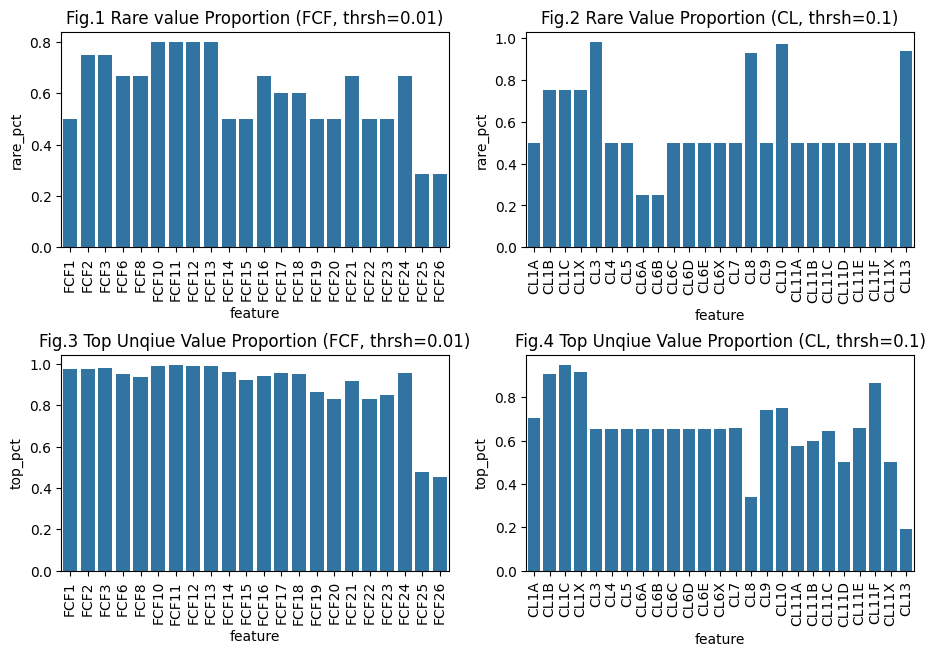

In [10]:
fig, ax = plt.subplots(2,2,figsize=(11,7))
df_card_fcf = get_cardinality(df, [feature for feature in df.columns if ('FCF' in feature)])
df_card_cl = get_cardinality(df, [feature for feature in df.columns if ('CL' in feature)], rare_threshold=0.1)

sns.barplot(df_card_fcf, x="feature", y="rare_pct", ax=ax[0,0])
ax[0,0].tick_params(axis='x', labelrotation=90)
ax[0,0].set_title("Fig.1 Rare value Proportion (FCF, thrsh=0.01)")

sns.barplot(df_card_cl, x="feature", y="rare_pct", ax=ax[0,1])
ax[0,1].tick_params(axis='x', labelrotation=90)
ax[0,1].set_title("Fig.2 Rare Value Proportion (CL, thrsh=0.1)")

sns.barplot(df_card_fcf, x="feature", y="top_pct", ax=ax[1,0])
ax[1,0].tick_params(axis='x', labelrotation=90)
ax[1,0].set_title("Fig.3 Top Unqiue Value Proportion (FCF, thrsh=0.01)")

sns.barplot(df_card_cl, x="feature", y="top_pct", ax=ax[1,1])
ax[1,1].tick_params(axis='x', labelrotation=90)
ax[1,1].set_title("Fig.4 Top Unqiue Value Proportion (CL, thrsh=0.1)")

plt.subplots_adjust(hspace=0.5)
plt.show()

In [11]:
df_card_fcf['top_category'].value_counts()

top_category
NO DIFFICULTY    13
NO                3
NEVER             2
Name: count, dtype: int64

Figures 1 and 2 above show the percentage of per-feature rows (that take values in that feature's set of unique values) which occur less than $100\times$`rare_threshold`$\in\\{1\\%,10\\%\\}$ of the time. Figures 3 and 4 show the percentage of each features rows in which the most-frequent unique value occurs. For features in the `FCF` module, the negative answer `NO DIFFICULTY` is most common (as seen in code cell above), which indicates that most children are well-functioning. 

The `FCF26` bar in Fig.3 shows that $40\%$ of the dataset consists of happy children (i.e. children never feeling depressed), and that most children are well functioning since `FCF_X` features usually correspond to questions concerning negative feelings (e.g. anxiety, difficulties, etc..) and the predominant answers are most of the time `NEVER` or `NO DIFFICULTY`. 

#### Preprocessing

Most of these columns are categorical, and even the "numerical" features have their constituents represented as strings, often with an additional `NO RESPONSE` or `DK` answer, necessitating the use of sophicsticated pipelines. See class `PreProcessor` section 6 in the code for more details.

In [12]:
num_features = ['CL13', 'CL8', 'CL3', 'CL10', 'FL20A', 'FL20B', 'FLB20A', 'FLB20B', 'FL2H', 'FL2M',
                'LS2', 'MA2', 'MA4', 'MA11', 'MA8Y', 'TA2', 'TA15', 'TA17',
                'MLS2', 'MTA2', 'MTA15', 'MTA17',
                'HC18D', 'HC18E', 'HC18G', 'HC18H', 'ST4N$1', 'ST4N$2', 'ST4N$3', 'ST4N$4', 'ST4N$5', 'WS4', 'WS5', 'WS6', 'HC3', 'HC16A', 'HC18A', 'HC18B', 'HC18C', 'HC18F']

After identifying numerical features, we identify a small subset of features who would benefit from one-hot encoding (e.g. features whose corresponding questionare questions have binary responses or binary with a third "don't know" or "no response/attempt" answer). These features will be encoded with one-hot-encoding.
Although one-hot encoding results in more features and higher dimensionality of the dataset $X\in\mathbb{R}^{n\times d}$, we will later determine which modules or features are redundant and apply PCA to reduce the number of features before fitting our models.

In [13]:
one_hot_features = ["FL1", "HC8", "MVT8", "MVT19", "MA5", "MA1"]

Finally, we use ordinal enoders where there is a sense of order to the response (e.g. levels of happiness, distance, or time duration). Columns not specified are dropped so the final set of features is a subset of all features in the modules in the `modules` list above.

Additionally, we consider `NaN` responses to be indicative of no response i.e. this was an inputing error on the survey's administrator's part, who left the field blank when the participant failed to respond to the question.

In [14]:
class RepeatedOrdinalEncoder(BaseEstimator, TransformerMixin):
    def __init__(self, order):
        '''
        This class extends TransformerMixin (defines fit_transform) and BaseEstimator 
        It assumes that all columns share the same ordered categories, and allows including 
        these kind of ordinal encoders in later pipelines
        '''
        self.order = order

    def fit(self, X, y=None):
        self.enc = OrdinalEncoder(
            # replicates ordinal categories so that each input row has same ordinal encoding
            categories=[self.order] * X.shape[1], 
            handle_unknown='use_encoded_value',
            unknown_value=np.nan
        )
        self.enc.fit(X)
        return self

    def transform(self, X):
        return self.enc.transform(X)

    # required for retrieving feature names downstream
    def get_feature_names_out(self, input_features=None):
        return input_features

In [15]:
class PreProcessor(ColumnTransformer):
    def __init__(self, df, features, one_hot_features=[], num_features=[]):
        self.num_features = num_features
        self.one_hot_features = one_hot_features
        self.ord_features = [] # filled later
        self.features = features # subset of df.columns
        self.df = df
        
        self.transformers= dict()
        self.transformers['ord'] = []
        self.transformers['num'] = []
        self.transformers['one_hot'] = []
        
        self.encode_ord()
        self.encode_num()
        self.encode_one_hot()
        
        transformers = self.transformers['one_hot'] + self.transformers['ord'] + self.transformers['num']
        super().__init__(transformers=transformers, verbose_feature_names_out=True,remainder='drop')
        
    def encode_ord(self):
        ordinal_answer_orders = dict()
        ordinal_answer_orders['yn'] = ['NO', 'YES', 'NO RESPONSE']
        ordinal_answer_orders['yndk'] = ['NO', 'YES', 'DK', 'NO RESPONSE']
        ordinal_answer_orders['cinr'] = ['CORRECT', 'INCORRECT', 'NOT REACHED']
        ordinal_answer_orders['cina'] = ['CORRECT', 'INCORRECT', 'NO ATTEMPT']
        ordinal_answer_orders['do'] = ['NO DIFFICULTY', 'SOME DIFFICULTY', 'A LOT OF DIFFICULTY']
        ordinal_answer_orders['freq'] = ['NEVER', 'A FEW TIMES A YEAR', 'MONTHLY', 'WEEKLY', 'DAILY', 'NO RESPONSE']
        ordinal_answer_orders['freq2'] = ['ONLY ONCE', 'MORE THAN ONCE']
        ordinal_answer_orders['freq3'] = ['ONE TIME', 'TWO TIMES', 'THREE OR MORE TIMES']
        ordinal_answer_orders['time_ago'] = ['MONTHS AGO', 'YEARS AGO']
        ordinal_answer_orders['time_ago2'] = ['YES, DURING THE LAST 12 MONTHS', 'NO, MORE THAN 12 MONTHS AGO']
        ordinal_answer_orders['people'] = ['ONE PERSON', 'THREE OR MORE PEOPLE', 'TWO PEOPLE'] 
        ordinal_answer_orders['grade'] = ['CLASS/YEAR/GRADE 1', 'CLASS/YEAR/GRADE 2', 'CLASS/GRADE 3', 'CLASS/YEAR/GRADE 4',
                                          'CLASS/GRADE 5', 'CLASS/GRADE 6', 'CLASS/YEAR/GRADE 7', 'CLASS/YEAR/GRADE 8']
        ordinal_answer_orders['edu'] = ['ECE', 'LOWER SECONDARY', 'PRIMARY', 'UPPER SECONDARY', 'VOCATION TRAINING', 'HIGHER']
        
        ordinal_answer_types = ['do', 'yn', 'yndk', 'cinr', 'cina', 'freq', 'freq2', 'freq3',
                        'time_ago', 'time_ago2', 
                        'grade', 'edu', 'people']
        ord_features_table = {key:[] for key in ordinal_answer_types}
        
        nan_resp = ['no response', 'dk', 'no attempt', 'not reached', 'no difficulty']

        for feature in set(self.features).difference(set(self.num_features)).difference(set(self.one_hot_features)):
            uresp = self.df[feature].unique()
        
            # 1. Replace nan-equivalent responses
            for resp in nan_resp:
                mask = np.array([resp in str(s).strip().lower() for s in uresp])
                if any(mask):
                    self.df.loc[self.df[feature].isnull(),feature] = str(uresp[mask][0])
        
            # 2. Replace missing values in binary columns with NO
            if(set(self.df[feature].unique()) == {'NO', 'YES', np.nan}):
                self.df.loc[self.df[feature].isnull(),feature] = 'NO'
                self.one_hot_features.append(feature)
                continue # these will be passed to one-hot encoder
                
            # 3. Features with yes/no or correct/incorrect responses should be one-hot encoded
            if((any('yes' in str(s).strip().lower() for s in self.df[feature].unique()) and \
                any('no' in str(s).strip().lower() for s in self.df[feature].unique())) or \
               (any('correct' in str(s).strip().lower() for s in self.df[feature].unique()) and \
                any('incorrect' in str(s).strip().lower() for s in self.df[feature].unique()))):
                one_hot_features.append(feature)
                continue # these will be passed to one-hot encoder
            
            # 4. Group the ordinal columns
            if any('no difficulty' in str(s).strip().lower() for s in self.df[feature].unique()) or \
               any('some difficulty' in str(s).strip().lower() for s in self.df[feature].unique()) or \
               any('a lot of difficulty' in str(s).strip().lower() for s in self.df[feature].unique()):
                ord_features_table['do'].append(feature)
        
            if (any('weekly' in str(s).strip().lower() for s in self.df[feature].unique()) and \
                any('daily' in str(s).strip().lower() for s in self.df[feature].unique())):
                    ord_features_table['freq'].append(feature)
        
            if any('one time' in str(s).strip().lower() for s in self.df[feature].unique()):
                    ord_features_table['freq2'].append(feature)
                
            if any('only once' in str(s).strip().lower() for s in self.df[feature].unique()):
                    ord_features_table['freq3'].append(feature)
                
            if (any('years ago' in str(s).strip().lower() for s in self.df[feature].unique()) and \
                any('months ago' in str(s).strip().lower() for s in self.df[feature].unique())):
                    ord_features_table['time_ago'].append(feature)
        
            if any('class/year/grade' in str(s).strip().lower() for s in self.df[feature].unique()):
                    ord_features_table['grade'].append(feature)
                
            if any('lower secondary' in str(s).strip().lower() for s in self.df[feature].unique()):
                    ord_features_table['edu'].append(feature)
                
            if any('one person' in str(s).strip().lower() for s in self.df[feature].unique()):
                    ord_features_table['people'].append(feature)
                
        def replace_dk(X):
            X = pd.DataFrame(X).copy()
            X = X.astype(object)
            dk_variants = [v for v in X.stack().unique() if str(v).startswith('DK')]
            return X.replace(dk_variants, np.nan)
        
        def get_pipeline(answer_type):
            return Pipeline([
                ('replace_dk', FunctionTransformer(replace_dk, feature_names_out='one-to-one')),
                ('ordinal', RepeatedOrdinalEncoder(order=ordinal_answer_orders[answer_type])),
                ('impute', SimpleImputer(strategy='mean')),
            ])
        
        # 5. create column-wise transformers with an inputing strategy for ordinal encodings too
        for answer_type in ['edu', 'grade', 'time_ago']:
            self.transformers['ord'].append((answer_type, get_pipeline(answer_type), ord_features_table[answer_type]))

        for feature in ord_features_table['do']:
            if(len(self.df[feature].unique()) > 2):
                # this generalizes the last encoding since many different questions all have variants
                # of a negative response that starts of the form "Cannot __"
                cannot_labels = [v for v in self.df[feature].unique() if str(v).startswith('CANNOT')]
                order = ordinal_answer_orders['do'] + cannot_labels + ['NO RESPONSE']
                self.transformers['ord'].append((feature, OrdinalEncoder(categories=[order]), [feature]))
            else:
                self.one_hot_features.append(feature) # these are essentially binary features now

        for t in [ans for ans in ordinal_answer_types if ans not in ['do','edu','grade','time_ago']]:
                self.transformers['ord'].append((t, OrdinalEncoder(
                    categories=[ordinal_answer_orders[t]]*len(ord_features_table[t])),ord_features_table[t]))
            
    def encode_num(self):
        # 6. encode string responses in numerical features
        def parse_num_value(v):
            if isinstance(v, str):
                if v.startswith('NEVER') or v.startswith('MEMBERS'):
                    return 0.0
                if v in ['NO RESPONSE', 'DK']:
                    return np.nan
                v = v.replace('+','')
            return float(v)
        
        def clean_num_col(X):
            X = X.copy()
            for col in X.columns:
                X[col] = X[col].apply(parse_num_value)
            return X
        
        self.transformers['num'].append(('num', Pipeline([
            ('clean', FunctionTransformer(clean_num_col, feature_names_out='one-to-one')),
            ('impute', SimpleImputer(strategy='mean')), # mean inputer 
        ]), self.num_features))
        
    def encode_one_hot(self):
        self.transformers['one_hot'].append(('one_hot', OneHotEncoder(drop='first',handle_unknown='ignore', 
                                                                      sparse_output=False), self.one_hot_features))


The `PreProcessor` class above extends `ColumnTransformer` and allows for custom ordinal encoding and numerical encoding. 

**Part 1** addresses the `NaN` values. These null entries are replaced by the appropriate question response in `nan_resp` (e.g. `NO RESPONSE`or `DK`) based on the unique values for that feature.

**Part 4** appears daunting but this is just creating a mapping between features and ordinal encoding types so that the right transformers can be created later (Part 6); it does so by checking whether unique responses include certain keywords and routes those features to an ordinal encoding type.

**Part 5** in class member function `encode_ord()` requires more discussion. Some features (e.g. grade-level or education level) are ordinally encoded via `get_pipeline()` which first replaces `DK` answers with `NaN` and then imputes the `NaN` with the average *encoded* response (so we take the average encoding of the level to be that participant's answer); this function is applied to a subset of answer types. 

This class allows for modular reconfiguration of the preprocessor pipeline, so that we can easily add and remove features to the encodings which we deem necessary and/or significant

In [16]:
pre_processor = PreProcessor(df, features, num_features=num_features, one_hot_features=one_hot_features)

Since we are dealing with binary classification of no feelings of depression vs any feelings of depression, we encode the target variable as follows:

In [17]:
for df_it in [df, df_base]:
    target_mask = df_it['FCF26'].isnull() | (df_it['FCF26'] == 'NO RESPONSE') | (df_it['FCF26'] == 'NEVER')
    df_it['FCF26'] = (target_mask).astype(bool)

In [18]:
features = get_features(df, modules, excl_features)

The dataset is split into training and testing subsets using `train_test_split`, with `test_size=0.2`, a fixed `random_state` for reproducibility, while preserving the class distribution through the use of `stratify=y`. Stratification ensures that both the training and test sets maintain approximately the same proportion of each target class, which is particularly important in preventing underrepresentation of minority classes and leads to more reliable model evaluation.

In [19]:
y = df['FCF26']
X = df.drop(columns=['FCF26'])
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=random_state, stratify=y)

In [20]:
%%capture
pre_processor.fit_transform(X_train[features])

In [21]:
%%capture
df_clean = pd.DataFrame(pre_processor.fit_transform(X_train[features]), columns=pre_processor.get_feature_names_out())

#### Feature Selection

We perform Chi-squared tests to narrow-down which features are dependent with the target variable.
Let $X$ be a categorical covariate (i.e. a feature in `X_train`) taking values in set $S=\{X_0,\ldots,X_k\}$ where $k\in\mathbb{Z}$, and let $Y$ be the target feature (i.e. child depression binary variable `FCF26`). 

$ \newcommand{\ind}{\perp\!\!\!\!\perp} $
Let $\text{H}_0: X\ind Y$. We will use significance level $\alpha=5\%$.

We then calculate Cramer's V for the response variable $V=\sqrt{\frac{\chi^2}{n}}$ where $n$ is the number of observations in the dataset and $\chi^2$ is the Chi-squared statistic. This statistic measures the dependence of $X$ on $Y$, and is a reasonable statistic to include because the $\chi^2$ value scales linearly with $n$.

We perform this statistical test for all encoded features extracted from the `modlues` list.

In [22]:
def get_features_pre(df_in, modules, excl_features=[]): # get all features in all modules for a preprocessed dataframe
    features = []
    for module in modules:
        features = features + [feature for feature in df_in.columns if (module in feature) and feature not in excl_features]
    return features

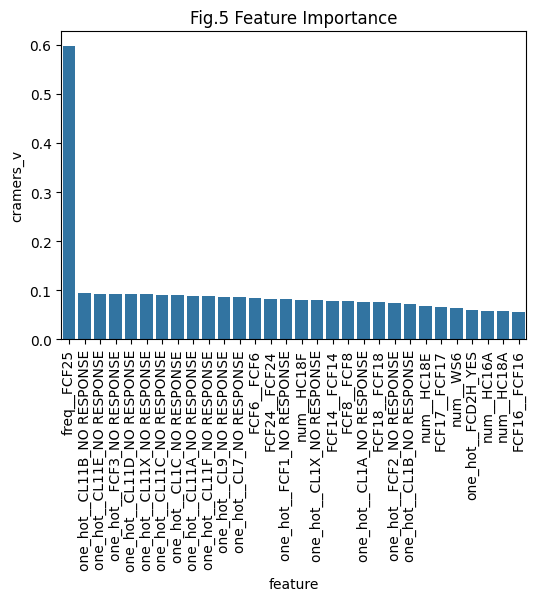

Table 1. Feature Importance


,chi2,log_chi2,p_value,cramers_v
feature,,,,
freq__FCF25,5134.877829,8.543811,0.000000e+00,0.597566
one_hot__CL11B_NO RESPONSE,125.525122,4.832506,3.906135e-29,0.093430
one_hot__CL11E_NO RESPONSE,123.178686,4.813636,1.274394e-28,0.092553
one_hot__FCF3_NO RESPONSE,123.178686,4.813636,1.274394e-28,0.092553
one_hot__CL11D_NO RESPONSE,122.034085,4.804300,2.269060e-28,0.092122


In [23]:
cleaned_features = get_features_pre(df_clean, modules)
# perform chi-sq test of H_0 on training set and calculate Cramer's v
chi2_scores, p_values = chi2(df_clean[cleaned_features], y_train) 
cramers_v = np.sqrt(chi2_scores / y_train.shape[0])
df_imp = pd.DataFrame({
    'feature': cleaned_features,
    'chi2': chi2_scores,
    'log_chi2': np.log(chi2_scores),
    'p_value': p_values,
    'cramers_v': cramers_v,
}).sort_values('cramers_v',ascending=False)
df_imp.set_index('feature',inplace=True)

fig,ax = plt.subplots(1,1,figsize=(6,4))
sns.barplot(df_imp.iloc[:30], x='feature', y='cramers_v', ax=ax)
ax.tick_params(axis='x', labelrotation=90)
ax.set_title("Fig.5 Feature Importance")
plt.show()

print("Table 1. Feature Importance")
display(df_imp.loc[df_imp.iloc[:5].index])

Figure 5 shows a $v>\delta:=0.1$ for feature `FCF25`, which corresponds to survey question "I would like to know how often (name) seems very anxious, nervous or worried." with answers: `[Daily, Weekly, Monthly, A few times a year, Never]`. 
Since depression often comes with anxiety [1], it comes as no surprise that these two variables are dependent. However, due psychological association of the two states, `FCF25` may function as a proxy for depression itself (i.e. target variable `FCF26`), so we may be justified in removing it from the training set. 

Moreover, the table above shows that although `CL11B` and `CL11E` one-hot encodings $p<<\alpha$ (i.e. we strongly reject $\text{H}_0$ for these features), we have that $v<\delta$ so these variables do not hold much signal.

$ \newcommand{\ind}{\perp\!\!\!\!\perp} $
In other words, the data supports *dependence* $P(Y=y|X=x)\neq P(Y=y)$,
but since $v<\delta\implies P(Y=1|\,X=X_1)\approx P(Y=1|\,X=X_i)$ where $i\in\{1,\ldots,k\}$ 

Knowing this, we can move forward in our modeling with adjusted expectations. 

#### PCA

Since one-hot encoding increases $d$ for dataset $X\in\mathbb{R}^{n\times d}$, we perform PCA to reduce the dimensionality of the dataset before training any models.

In [24]:
%%capture
eda_pipe = Pipeline([
    ('pre',pre_processor),
    ('pca', PCA())
])
eda_pipe.fit_transform(X_train)

In [25]:
proportion_of_variance = eda_pipe['pca'].explained_variance_ratio_
proportion_of_variance_cum = np.cumsum(proportion_of_variance)

optimal_components = np.argmax(proportion_of_variance_cum >= 0.95) + 1
total_variance_explained = proportion_of_variance_cum[optimal_components-1] * 100

print(f"Optimal number of components: {optimal_components}")
print(f"Total percentage of variance explained by optimal components: {total_variance_explained:.4f}")

Optimal number of components: 13
Total percentage of variance explained by optimal components: 95.0932


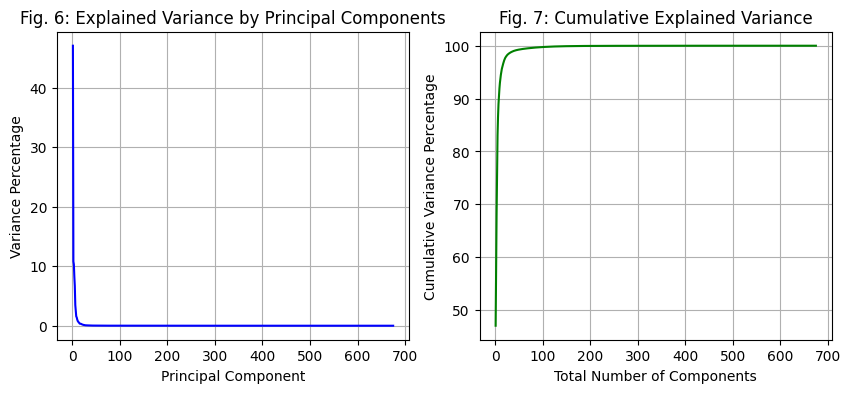

In [26]:
fig,ax = plt.subplots(1,2,figsize=(10,4))

ax[0].plot(range(1, len(proportion_of_variance) + 1), proportion_of_variance * 100, 'b-')
ax[0].set_xlabel('Principal Component')
ax[0].set_ylabel('Variance Percentage')
ax[0].set_title('Fig. 6: Explained Variance by Principal Components')
ax[0].grid(True)

ax[1].plot(range(1, len(proportion_of_variance_cum) + 1), proportion_of_variance_cum * 100, 'g-')
ax[1].set_xlabel('Total Number of Components')
ax[1].set_ylabel('Cumulative Variance Percentage')
ax[1].set_title('Fig. 7: Cumulative Explained Variance')
ax[1].grid(True)

plt.show()

Figure 7 shows that only the first 13 principal components from PCA explain approximately 95.3% of the total variance. Therefore, a lower-dimensional representation can effectively preserve most of the underlying signal.
The fact that most of the variance is caputed in so few components is supported by the previous section's chi-squared tests, where we found that most features have low predictive power for determining child depression (see Fig.5), and are likely aggregated into the orthonormal basis vectors via PCA.

# Model Fitting and Tuning

All model development activities including exploratory data analysis, feature engineering, model training, and hyperparameter tuning are conducted exclusively on the training set (`X_train`, `y_train`). The test set (`X_test`, `y_test`) is held out entirely and not exposed to any fitting or tuning procedures, ensuring an unbiased evaluation.

We begin with an interpretable baseline model using `Logistic Regression`, chosen for its simplicity. This baseline provides a clear reference point against which more complex modeling choices can be evaluated. To improve performance while retaining interpretability, we incorporate `StandardScaler` (used for both numerical and catagorical features) and `PCA` within a single pipeline. 

In [27]:
# We used unicef_malawi.csv dataset for the baseline model

y_b = df_base['FCF26']
X_b = df_base.drop(columns=['FCF26'])
X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(X_b, y_b, test_size=0.2, random_state=random_state, stratify=y_b)

In [28]:
features_base = get_features(df_base, modules, excl_features)
pre_processor_base = PreProcessor(df_base, features_base, 
                                num_features=list(set(num_features).intersection(set(features_base))), 
                                one_hot_features=list(set(one_hot_features).intersection(set(features_base)))) 

In [29]:
pipeline_logistic_base = Pipeline([
    ('pre', pre_processor_base),
    ('scaler', StandardScaler(with_mean=False)),
    ('pca', PCA(n_components=0.95, random_state=random_state)),
    ('classifier', LogisticRegression(max_iter=5000,random_state=random_state)) # default L2 regularization
])

In [30]:
%%capture
pipeline_logistic_base.fit(X_train_b[features_base],y_train_b)

In [31]:
y_train_b_pred = pipeline_logistic_base.predict(X_train_b)
train_accuracy_b = accuracy_score(y_train_b, y_train_b_pred)
print(f"Baseline Train Accuracy: {train_accuracy_b:.4f}")

Baseline Train Accuracy: 0.5842


Note that we trained a simple logistic regression model on a subset of the features from the provided starter dataset `unicef_malawi.csv`. However, the training accuracy was quite low at 58.42%. 
Hence, we will now the same model train on a larger feature set from the extended data sources dataset.

In [32]:
pipeline_logistic = Pipeline([
    ('pre', pre_processor),
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=0.95, random_state=random_state)),
    ('classifier', LogisticRegression(max_iter=5000,random_state=random_state)) # default L2 regularization
])

In [33]:
%%capture
pipeline_logistic.fit(X_train[features], y_train)

As we have included PCA in the pipeline, `L2 regularization` is the more appropriate choice for logistic regression. PCA transforms the original features into a set of orthogonal (uncorrelated) components and captures the most important variance in a lower dimensional space. Thus, the primary advantage of L1 regularization (feature selection) is less relevant here. Hence, L2 regularization is better suited here as it shrinks coefficients smoothly and provides greater numerical stability.

In [34]:
y_train_pred = pipeline_logistic.predict(X_train[features])
train_accuracy = accuracy_score(y_train, y_train_pred)
print(f"Train Accuracy: {train_accuracy:.4f}")

Train Accuracy: 0.8560


In [35]:
print(classification_report(y_train, y_train_pred))

              precision    recall  f1-score   support

       False       0.88      0.85      0.86      7695
        True       0.83      0.87      0.85      6685

    accuracy                           0.86     14380
   macro avg       0.86      0.86      0.86     14380
weighted avg       0.86      0.86      0.86     14380



We ran the code below which uses Cross-Validation on k-folds to find the optimal value of the *inverse* of the $\ell_2$-regularization parameter, denoted `C` in the `sklearn` framework.
However, for the sake of notebook runtime, we are presenting it in markdown format instead of in an IPython cell.

```
warnings.simplefilter("ignore") # ignore deprecation warnings

param_grid_logistic = {
    'classifier__C': np.linspace(0.01, 10, 100)  # 100 values between 0.01 and 10
}

grid_logistic  = GridSearchCV(
    pipeline_logistic,
    param_grid_logistic,
    cv=5,
    scoring='recall',
    error_score='raise',
    n_jobs=-1 # use all CPU cores
)

grid_logistic.fit(X_train[features], y_train)

print("Params: ", grid_logistic.best_params_)
print("Avg CV Recall: ", grid_logistic.best_score_)
```

The model is now refined through hyperparameter tuning using cross-validated grid search, focusing on the regularization strength *inverse* parameter `C`. This process identifies an optimal value of `C = 9.29`. The resulting tuned logistic regression model serves as our primary candidate.

In [36]:
pipeline_logistic_opt = Pipeline([
    ('pre', pre_processor),
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=0.95, random_state=random_state)),
    ('classifier', LogisticRegression(max_iter=5000, C=9.29, random_state=random_state))
])

In [37]:
%%capture
pipeline_logistic_opt.fit(X_train[features], y_train)

In [38]:
y_train_pred = pipeline_logistic_opt.predict(X_train)
train_accuracy = accuracy_score(y_train, y_train_pred)
print(f"Train Accuracy: {train_accuracy:.4f}")

Train Accuracy: 0.8559


We considered using an `Support Vector Classifier (SVC)` model with an RBF kernel to capture potential non-linear relationships in the data. Since after fine-tuning $\ell_2$ regularization parameter for both models, the Logisitic Regression model had a similary accuracy of 85%, while the SVC model accuracy increased by 3%. We suspect that this 3% increase in SVC accuracy was the result of overfitting the training data. Moreover, the fine-tuned SVC model's accuracy dropped 6.5% on the cross-validation dataset. Hence, we prefer the fine-tuned Logistic Regression model on the extended dataset.

#### Final Model Testing

In [39]:
y_test_pred = pipeline_logistic_opt.predict(X_test)
test_accuracy = accuracy_score(y_test, y_test_pred)
print(f"Test Accuracy: {test_accuracy:.4f}")

Test Accuracy: 0.8521


In [40]:
print("Table 2. Logistic Regression Classification Report (final)\n", classification_report(y_test, y_test_pred))

Table 2. Logistic Regression Classification Report (final)
               precision    recall  f1-score   support

       False       0.88      0.83      0.86      1924
        True       0.82      0.88      0.85      1672

    accuracy                           0.85      3596
   macro avg       0.85      0.85      0.85      3596
weighted avg       0.85      0.85      0.85      3596



In [41]:
# calculate the ROC curve on the baseline model using the baseline test dataset
y_prob_b = pipeline_logistic_base.predict_proba(X_test)[:, 1]
fpr_b, tpr_b, _ = roc_curve(y_test, y_prob_b)
roc_auc_b = auc(fpr_b, tpr_b)

In [42]:
y_prob = pipeline_logistic_opt.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

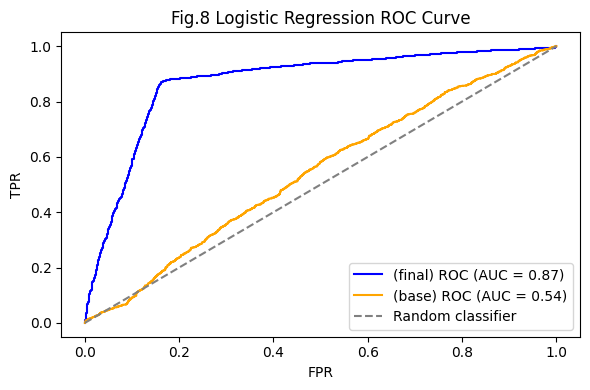

In [43]:
fig, ax = plt.subplots(1,1,figsize=(6,4))
ax.plot(fpr, tpr, label=f"(final) ROC (AUC = {roc_auc:.2f})", color="blue")
ax.plot(fpr_b, tpr_b, label=f"(base) ROC (AUC = {roc_auc_b:.2f})", color="orange")
ax.plot([0, 1], [0, 1], color="gray", linestyle="--", label="Random classifier")
ax.set_xlabel("FPR")
ax.set_ylabel("TPR")
ax.set_title("Fig.8 Logistic Regression ROC Curve")
plt.legend()
plt.tight_layout()
plt.show()

Hence by training on a larger feature set, and by optimizating the $\ell_2$-regularization parameter via k-folds cross-validation, we obtain a binary logistic classifier with a greater AUC. Note that the baseline model performs only slightly better than chance (diagonal line).

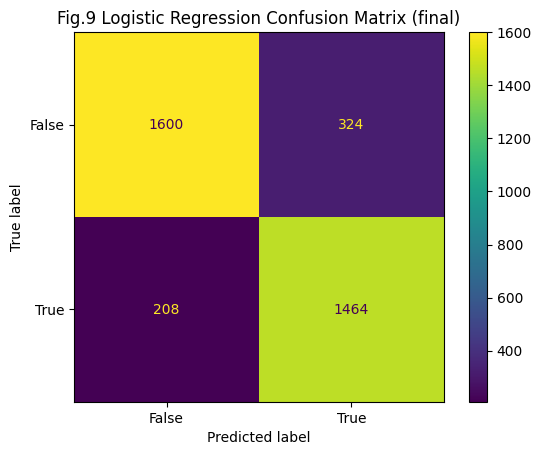

In [44]:
cm = confusion_matrix(y_test, y_test_pred, labels=pipeline_logistic_opt.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=pipeline_logistic_opt.classes_)
disp.plot()
plt.title("Fig.9 Logistic Regression Confusion Matrix (final)")
plt.show()

# Interpretation, Discussion & Conclusions

Through this project, we sought to build a model to determine, based on survey question responses, whether a child is depressed or not, and achieved a model with 85% predictive accuracy on unseen data. In our final model, we only considered a subset of the survey modules for our dataset e.g. Child Functioning, Life Satisfaction (see EDA section for full list).

A potential use-case of such a model would be to match children to a limited number of state-funded psychology counseling resources. In this use-case, false negatives (i.e. incorrectly predicting that the child is *not* depressed) holds the highest risk. Fortunately, in our final model, there is a 12% chance that a depressed child is misclassified by the model as not depressed, and in this scenario would not be assigned counseling services (see Table 2). For instance, in a test sample of 3596 children, the model mis-classified 208 depressed children as not depressed (see fig.9).

Preliminary data analysis (see fig.5) shows that the biggest influences of child depression come from:
1. **<u>Family's Socioeconomic Status:</u>** Survey question `HC18` and `HC16A` have to do with hectares of land owned and number of livestock owned, which function as proxies for that child's household's wealth.
2. **<u>Child Disabilities:</u>** Insecurity about needing glasses, equipment to walk or hear, or having a speech impediment is evidence by the lack of responses i.e. `NO RESPONSE` to survey questions `FCF6` and `FCF14`.
3. **<u>Inability to make friends:</u>** Survey question `FCF24` also influences child depression, however perhaps this may not be a cause but an effect of depression since children feeling depressed are more likely to isolate themselves [2]
4. **<u>Child Labor:</u>** Children who offered no response to survey questions `CL11` or `CL1` may be hiding the amount of chores (e.g. carrrying firewood, laundry, looking after infants) they have to do, and prefer to skip that question. However there is little doubt that child labor is related to child mental health [3].

Perhaps it's important that children who have many chores or farm-work to do at home after school still have the opportunity to socialize with their peers, especially if that child comes from a LMIC household [3]. Favoring these children for counseling services would alleviate feelings of depression for who likely show signs for it.

Nevertheless, this model does not take into account the frequency of depressive feelings. Survey question `FCF26` is asked to the parent/guardian, "I would also like to know how often (name) seems very sad or depressed. Would you say: daily, weekly, monthly, a few times a year or never?"  An improvment to this model would be to also classify how often the child seems depressed. Instead of classifying their mental state as "never seems depressed" or "seems depressed X times per [time period]", we would classify exactly the frequency of their perceived depressive state e.g. `[Daily, Weekly, Monthly, A few times a year, Never]`, which would allow psychological counseling resources to be prioritized for children who are predicted to seem depressed more often.


# Generative AI statement

Generative AI was used to help with LaTeX syntax, and to do research into child depression in low-income countries.

# References

1. Möller, HJ., Bandelow, B., Volz, HP. et al. The relevance of ‘mixed anxiety and depression’ as a diagnostic category in clinical practice. Eur Arch Psychiatry Clin Neurosci 266, 725–736 (2016). https://doi.org/10.1007/s00406-016-0684-7

2. Schermer, J.A. et al. (2016). Social isolation, loneliness and depression in young adulthood: a behavioural genetic analysis. PMC4819590. https://pmc.ncbi.nlm.nih.gov/articles/PMC4819590/

3. Desmond, C. et al. (2025). Prevalence and correlates of child labour in five low-income countries including Malawi. PMC11749859. https://pmc.ncbi.nlm.nih.gov/articles/PMC11749859/